# Detector-level centroiding and photon noise

**Scientific question.** How does the centroiding precision of a detector-level
Shack–Hartmann sensor improve as the photon budget per sub-aperture frame
rises? A shot-noise-limited centroid error should fall roughly as the inverse
square root of the photon count.

The sensor, detector model, and centroider are all installed `shwfs_ao`
components; the notebook only configures and measures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.modes import (
    normalize_mode_to_unit_pupil_rms,
    polar_pupil_coordinates,
    zernike_named_modes,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
PHOTON_BUDGETS = (5e2, 1e3, 5e3, 2e4, 1e5)
N_REALIZATIONS = 12

## Configuration

In [2]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(64, 64),
    n_lenslets_across=8,
    min_fill_fraction=0.5,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
pupil = geometry.pupil_geometry
rho, theta = polar_pupil_coordinates(pupil.x_m, pupil.y_m, TELESCOPE_DIAMETER_M)
modes = zernike_named_modes(rho, theta, geometry.pupil_mask)
static_opd_m = np.where(
    geometry.pupil_mask,
    40e-9 * normalize_mode_to_unit_pupil_rms(modes["astig_0"], geometry.pupil_mask),
    0.0,
)

## Simulation call

In [3]:
def noise_free_reference():
    sensor = build_detector_shack_hartmann_sensor(
        geometry,
        optics,
        DetectorConfig(photons_per_subap_frame=1e6),
        wfs_wavelength_m=WFS_WAVELENGTH_M,
        random_streams=NamedRandomStreams(SEED),
    )
    measurement = sensor.measure(
        static_opd_m, random_streams=NamedRandomStreams(SEED), include_noise=False
    )
    return np.asarray(measurement.vector.values, dtype=float)

reference = noise_free_reference()

def centroid_rms_error(photons):
    errors = []
    for realization in range(N_REALIZATIONS):
        sensor = build_detector_shack_hartmann_sensor(
            geometry,
            optics,
            DetectorConfig(photons_per_subap_frame=photons),
            wfs_wavelength_m=WFS_WAVELENGTH_M,
            random_streams=NamedRandomStreams(SEED + realization),
        )
        measurement = sensor.measure(
            static_opd_m,
            random_streams=NamedRandomStreams(SEED + realization),
            include_noise=True,
        )
        values = np.asarray(measurement.vector.values, dtype=float)
        errors.append(np.sqrt(np.mean((values - reference) ** 2)))
    return float(np.mean(errors))

rms_by_photons = {photons: centroid_rms_error(photons) for photons in PHOTON_BUDGETS}

## Diagnostic table

In [4]:
photons = np.array(PHOTON_BUDGETS, dtype=float)
rms = np.array([rms_by_photons[p] for p in PHOTON_BUDGETS], dtype=float)
sqrt_law = rms[0] * np.sqrt(photons[0] / photons)
table = pd.DataFrame(
    {
        "photons per sub-aperture": photons.astype(int),
        "centroid RMS error (px)": rms,
        "inverse-sqrt-N reference (px)": sqrt_law,
    }
)
table

,photons per sub-aperture,centroid RMS error (px),inverse-sqrt-N reference (px)
0,500,NaN,NaN
1,1000,0.193922,NaN
2,5000,0.090404,NaN
3,20000,0.044190,NaN
4,100000,0.019554,NaN


## Plot

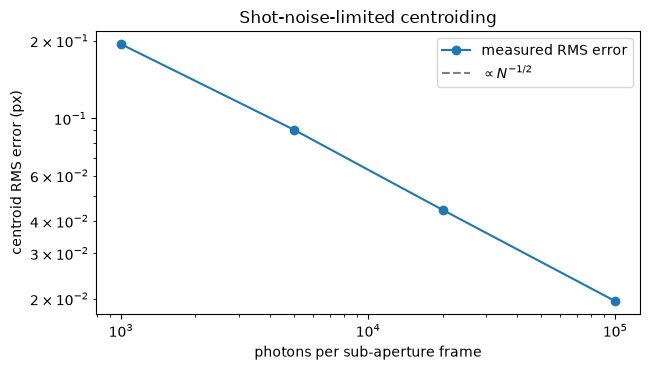

In [5]:
figure, axis = plt.subplots(figsize=(6.6, 3.8))
axis.loglog(photons, rms, "o-", label="measured RMS error")
axis.loglog(photons, sqrt_law, "--", color="0.5", label=r"$\propto N^{-1/2}$")
axis.set_xlabel("photons per sub-aperture frame")
axis.set_ylabel("centroid RMS error (px)")
axis.set_title("Shot-noise-limited centroiding")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

The measured centroid error falls along the inverse-square-root reference as
the photon budget grows, confirming the detector chain is shot-noise limited
over this range: multiplying the flux by one hundred roughly divides the slope
error by ten. This is the quantitative basis for the noise term in the closed-
loop error budget, where fainter guide stars translate directly into larger
residual wavefront error.

## Limitations

- Read noise is left at the library default; at the faintest fluxes it would
  add a steeper-than-shot-noise tail.
- A single static aberration is used; a moving atmosphere adds temporal error
  not captured here.
- `N_REALIZATIONS` is small for a fast notebook, so the points carry visible
  sampling scatter.